In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [35]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [36]:
x = df.drop(columns = ['math score'])
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [37]:
y = df['math score']

In [38]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [39]:
# creating column transformer with 3 types of transformers
num_features = x.select_dtypes(exclude = 'object').columns
cat_features = x.select_dtypes(include = 'object').columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(

    [

        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features)
    ]
)

In [40]:
x = preprocessor.fit_transform(x)

In [41]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2  , random_state= 42)
x_train.shape, x_test.shape


((800, 19), (200, 19))

In [61]:
# Creating an evaluation function to give all metrics after model training

def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,predicted)
    return mae,mse,r2,rmse


In [ ]:
models = {

    'Linear Regression' : LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge' : Ridge(),
    'K-Neighors Regressor' : KNeighborsRegressor(),
    'Decision Tree' : DecisionTreeRegressor(),
    'Random Forest' : RandomForestRegressor(),
    'XGBRegressor' : XGBRegressor(),
    'CatBoosting Regressor' : CatBoostRegressor(),
    'AdaBoostRegressor': AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]

    model.fit(x_train,y_train) # training the model(s)

    # Making predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)


# Evaluating the model
    model_train_mae , model_train_mse , model_train_r2 , model_train_rmse= evaluate_model(y_train,y_train_pred)
    model_test_mae, model_test_mse, model_test_r2 , model_test_rmse = evaluate_model(y_test,y_test_pred )

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])


    print("   Model performance for Training Set : ")
    print(" ------------------------------------------")
    print(f" -Root Mean Squared Error : {model_train_rmse:.4f}")
    print(f" -Mean Squared Error {model_train_mse:.4f}")
    print(f" -Mean Absolute Error {model_train_mae:.4f}")
    print(f" -R2 Score : {model_train_r2:.4f}") 


    print("   Model Performance for Test Data : ")
    print(" ------------------------------------------")

    print(f" -Root Mean Squared Error : {model_test_rmse:.4f}")
    print(f" -Mean Squared Error {model_test_mse:.4f}")
    print(f" -R2 Score : {model_test_r2:.4f}")
    print(f" -Mean Absolute Error : {model_test_mae:.4f}") 

    r2_list.append(model_test_r2)

    print('\n')
    print('='*40)
    print('\n')

Linear Regression
 Model performance for Training Set : 
 ------------------------------------------
 -Root Mean Squared Error : 5.3231
 -Mean Squared Error 28.3349
 -Mean Absolute Error 4.2667
 -R2 Score : 0.8743
 Model Performance for Test Data : 
 ------------------------------------------
 -Root Mean Squared Error : 5.3940
 -Mean Squared Error 29.0952
 -R2 Score : 0.8804
 -Mean Absolute Error : 4.2148




Lasso
 Model performance for Training Set : 
 ------------------------------------------
 -Root Mean Squared Error : 6.5938
 -Mean Squared Error 43.4784
 -Mean Absolute Error 5.2063
 -R2 Score : 0.8071
 Model Performance for Test Data : 
 ------------------------------------------
 -Root Mean Squared Error : 6.5197
 -Mean Squared Error 42.5064
 -R2 Score : 0.8253
 -Mean Absolute Error : 5.1579




Ridge
 Model performance for Training Set : 
 ------------------------------------------
 -Root Mean Squared Error : 5.3233
 -Mean Squared Error 28.3378
 -Mean Absolute Error 4.2650
 -R2

# Results 

In [70]:
pd.DataFrame(list(zip(model_list, r2_list) ) , columns = ['Model Name', 'R2_Score']).sort_values(by=['R2_Score'],ascending = False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoosting Regressor,0.851632
5,Random Forest,0.848918
8,AdaBoostRegressor,0.843964
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighors Regressor,0.783813
4,Decision Tree,0.755895


## Linear Regression

In [80]:
lin_model = LinearRegression()
lin_model = lin_model.fit(x_train,y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)
print(f"Accuracy of the model is : {score*100:.2f}" )

Accuracy of the model is : 88.04


### Plotting y_pred and y_test

Text(0, 0.5, 'Predicted')

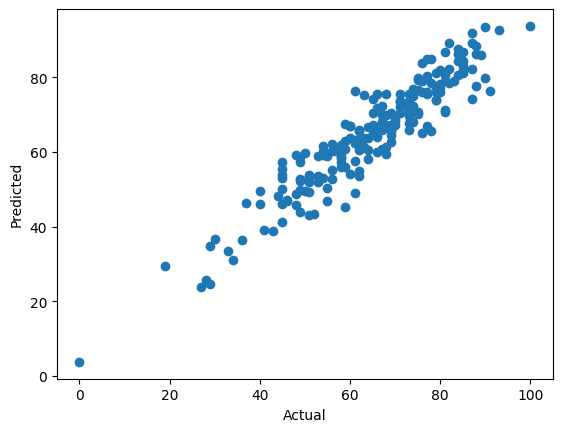

In [81]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math score'>

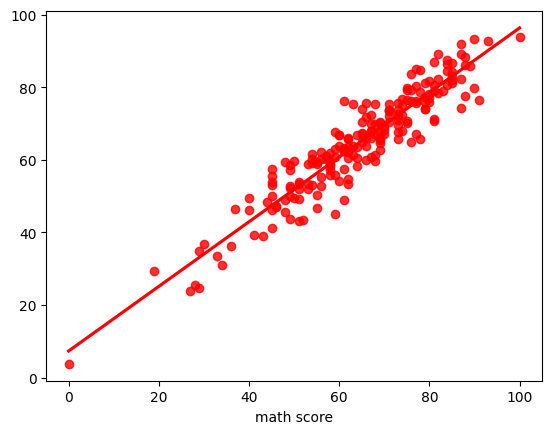

In [82]:
sns.regplot(x = y_test, y = y_pred, ci = None, color = 'Red')

### difference between actual and predicted values

In [85]:
pred_df = pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})

pred_df.head()

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
